In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os
import random 

sys.path.append('../') 
from src.preprocessing import load_data, clean_data, feature_engineer
from src.modeling import run_experiments

random.seed(42)
np.random.seed(42)

print(f"Текущий рабочий каталог: {os.getcwd()}")
print(f"Пути в sys.path: {sys.path}")

Текущий рабочий каталог: C:\Users\shche\PycharmProjects\Ml_project\hseml-group-project-alikashcherba\notebooks
Пути в sys.path: ['C:\\Users\\shche\\PycharmProjects\\Ml_project\\.venv\\Scripts\\python314.zip', 'C:\\Users\\shche\\AppData\\Local\\Programs\\Python\\Python314\\DLLs', 'C:\\Users\\shche\\AppData\\Local\\Programs\\Python\\Python314\\Lib', 'C:\\Users\\shche\\AppData\\Local\\Programs\\Python\\Python314', 'C:\\Users\\shche\\PycharmProjects\\Ml_project\\.venv', '', 'C:\\Users\\shche\\PycharmProjects\\Ml_project\\.venv\\Lib\\site-packages', '../']


In [2]:
from src.preprocessing import load_data, clean_data, feature_engineer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


data_path = '../data/raw/horse_racing_data.csv' 
df = load_data(data_path)

print("Исходный размер данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о типах данных:")
print(df.info())
print("\nСтатистическое описание числовых колонок:")
print(df.describe())
print("\nКоличество пропущенных значений:")
print(df.isnull().sum())

2026-04-25 00:07:08,500 - INFO - Загрузка данных из ../data/raw/horse_racing_data.csv...
2026-04-25 00:07:08,585 - INFO - Данные успешно загружены. Размер: (27008, 21)


Исходный размер данных: (27008, 21)

Первые 5 строк:
         Date    Track  Race Number  Distance Surface  Prize money  \
0  03.09.2017  Sha Tin           10      1400   Gress      1310000   
1  16.09.2017  Sha Tin           10      1400   Gress      1310000   
2  14.10.2017  Sha Tin           10      1400   Gress      1310000   
3  11.11.2017  Sha Tin            9      1600   Gress      1310000   
4  26.11.2017  Sha Tin            9      1600   Gress      1310000   

   Starting position         Jockey  Jockey weight  Country  ...  TrainerName  \
0                  6      K C Leung             52  Sverige  ...       CH Yip   
1                 14         C Y Ho             52  Sverige  ...       CH Yip   
2                  8         C Y Ho             52  Sverige  ...       CH Yip   
3                 13  Brett Prebble             54  Sverige  ...       CH Yip   
4                  9         C Y Ho             52  Sverige  ...       CH Yip   

  Race time Path  Final place  FGrating

In [3]:
df_cleaned = clean_data(df.copy())
print("\nРазмер данных после очистки:", df_cleaned.shape)
print("\nПропущенные значения после очистки:")
print(df_cleaned.isnull().sum())
print("\nТипы данных после очистки:")
print(df_cleaned.info())

2026-04-25 00:07:08,670 - INFO - Начало очистки данных...
2026-04-25 00:07:08,672 - INFO - Колонки после приведения к snake_case: ['date', 'track', 'race_number', 'distance', 'surface', 'prize_money', 'starting_position', 'jockey', 'jockey_weight', 'country', 'horse_age', 'trainername', 'race_time', 'path', 'final_place', 'fgrating', 'odds', 'racetype', 'horseid', 'jockeyid', 'trainerid']
2026-04-25 00:07:08,708 - INFO - Удалены колонки, вызывающие data leakage: ['race_time', 'path', 'fgrating']
2026-04-25 00:07:08,883 - INFO - Извлечен числовой возраст лошади из колонки 'horse_age'.
2026-04-25 00:07:08,893 - INFO - Очистка данных завершена. Размер: (27008, 18)



Размер данных после очистки: (27008, 18)

Пропущенные значения после очистки:
date                 0
track                0
race_number          0
distance             0
surface              0
prize_money          0
starting_position    0
jockey               0
jockey_weight        0
country              0
trainername          0
final_place          0
odds                 0
racetype             0
horseid              0
jockeyid             0
trainerid            0
horse_age            0
dtype: int64

Типы данных после очистки:
<class 'pandas.DataFrame'>
RangeIndex: 27008 entries, 0 to 27007
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               27008 non-null  datetime64[us]
 1   track              27008 non-null  str           
 2   race_number        27008 non-null  int64         
 3   distance           27008 non-null  int64         
 4   surface            27008 non-null

In [4]:
df_fe = feature_engineer(df_cleaned.copy())
print("\nРазмер данных после Feature Engineering:", df_fe.shape)
print("\nПервые 5 строк с новыми признаками и таргетом:")
print(df_fe.head())
print("\nРаспределение целевой переменной 'target':")
print(df_fe['target'].value_counts(normalize=True))

2026-04-25 00:07:08,924 - INFO - Начало создания новых признаков...
2026-04-25 00:07:08,976 - INFO - Добавлены временные признаки: year, month, day_of_week, day_of_year, race_season.
2026-04-25 00:07:08,979 - INFO - Добавлен признак prize_per_distance.
2026-04-25 00:07:08,980 - INFO - Добавлен признак jockey_weight_per_age.
2026-04-25 00:07:08,981 - INFO - Создан целевой признак 'target' (топ-3 или нет).
2026-04-25 00:07:08,984 - INFO - Удалена колонка 'final_place'.
2026-04-25 00:07:08,985 - INFO - Удалена колонка 'jockey' (используем jockeyid).
2026-04-25 00:07:08,986 - INFO - Создание новых признаков завершено.



Размер данных после Feature Engineering: (27008, 24)

Первые 5 строк с новыми признаками и таргетом:
        date    track  race_number  distance surface  prize_money  \
0 2017-09-03  Sha Tin           10      1400   Gress      1310000   
1 2017-09-16  Sha Tin           10      1400   Gress      1310000   
2 2017-10-14  Sha Tin           10      1400   Gress      1310000   
3 2017-11-11  Sha Tin            9      1600   Gress      1310000   
4 2017-11-26  Sha Tin            9      1600   Gress      1310000   

   starting_position  jockey_weight  country trainername  ...  trainerid  \
0                  6             52  Sverige      CH Yip  ...       6687   
1                 14             52  Sverige      CH Yip  ...       6687   
2                  8             52  Sverige      CH Yip  ...       6687   
3                 13             54  Sverige      CH Yip  ...       6687   
4                  9             52  Sverige      CH Yip  ...       6687   

  horse_age  year  month  

2026-04-25 00:07:09,054 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-25 00:07:09,074 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Директория для изображений: ../report/images


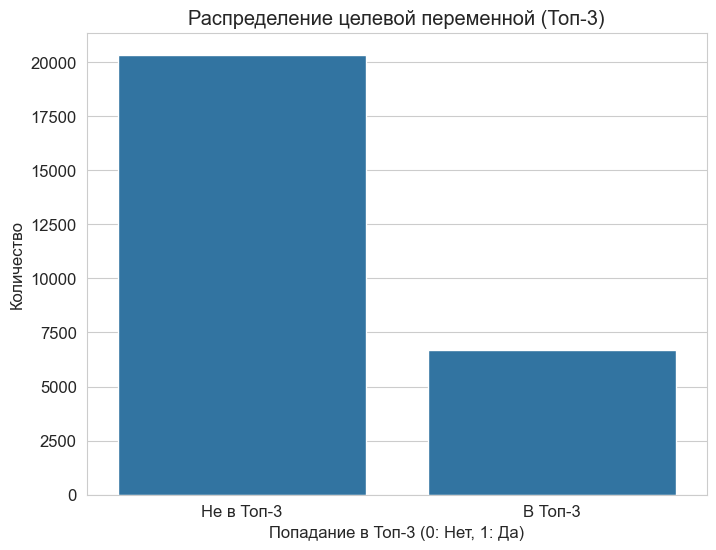

In [5]:
images_dir = '../report/images'
os.makedirs(images_dir, exist_ok=True)
print(f"\nДиректория для изображений: {images_dir}")

plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df_fe)
plt.title('Распределение целевой переменной (Топ-3)')
plt.xlabel('Попадание в Топ-3 (0: Нет, 1: Да)')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Не в Топ-3', 'В Топ-3'])
plt.savefig(os.path.join(images_dir, 'target_distribution.png'))
plt.show()

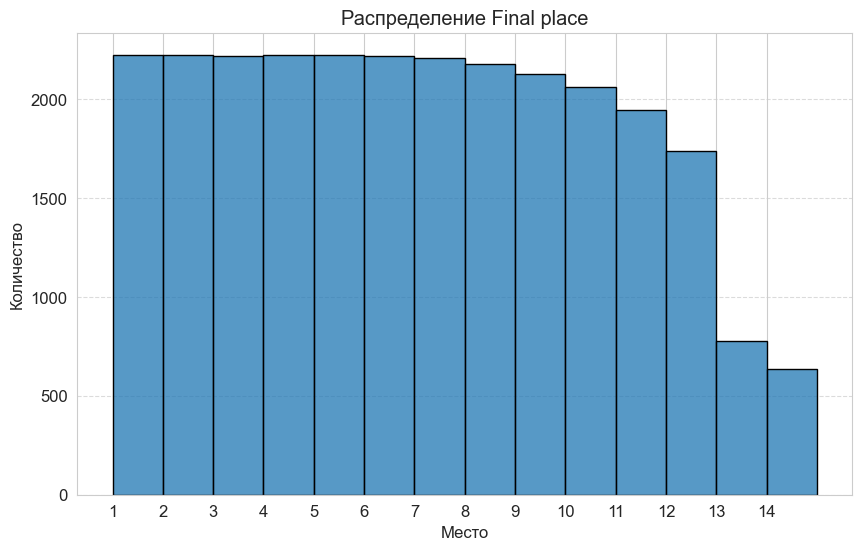

In [6]:
plt.figure(figsize=(10, 6))
if 'final_place' in df_cleaned.columns:
    max_place = df_cleaned['final_place'].max()
    sns.histplot(df_cleaned['final_place'], bins=range(1, int(max_place) + 2), kde=False, edgecolor='black')
    plt.title('Распределение Final place')
    plt.xlabel('Место')
    plt.ylabel('Количество')
    plt.xticks(range(1, int(max_place) + 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(images_dir, 'final_place_distribution.png'))
    plt.show()
else:
    print("Колонка 'final_place' отсутствует в df_cleaned. Пропустили график распределения мест.")

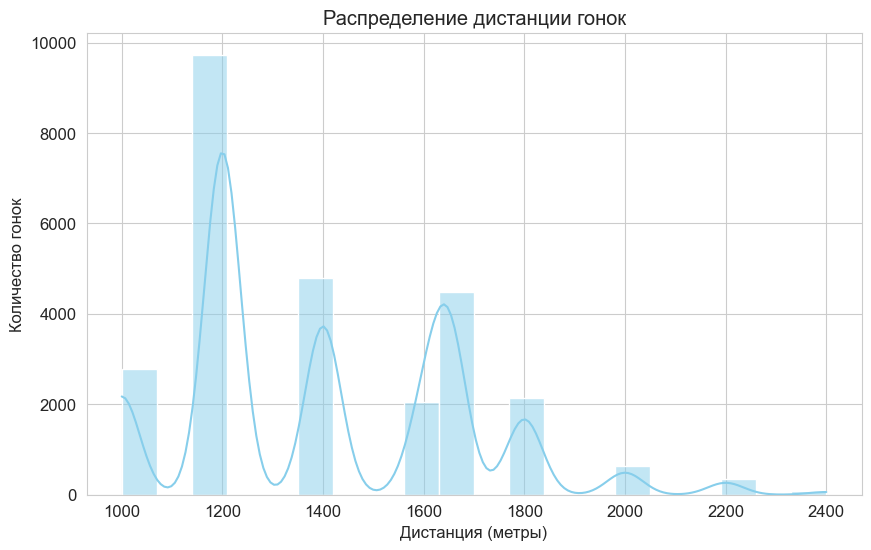

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_fe['distance'], bins=20, kde=True, color='skyblue')
plt.title('Распределение дистанции гонок')
plt.xlabel('Дистанция (метры)')
plt.ylabel('Количество гонок')
plt.savefig(os.path.join(images_dir, 'distance_distribution.png'))
plt.show()


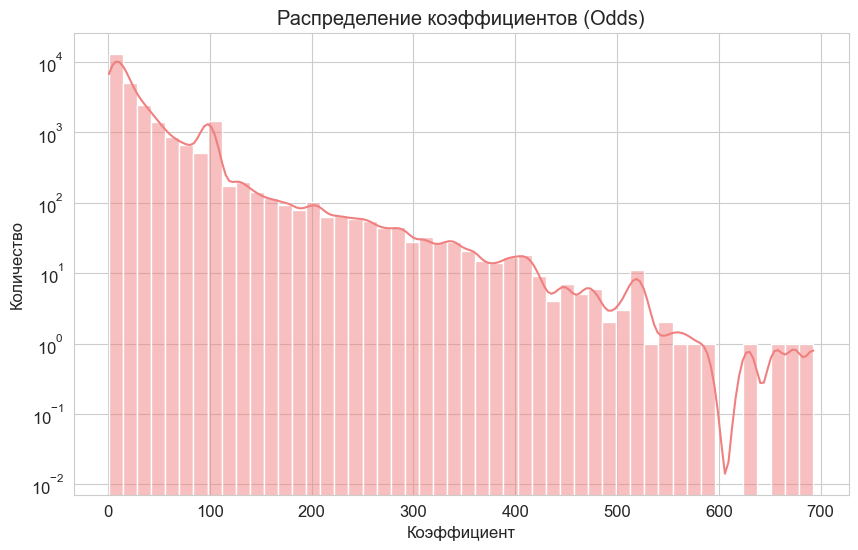

In [8]:

plt.figure(figsize=(10, 6))
sns.histplot(df_fe['odds'], bins=50, kde=True, color='lightcoral')
plt.title('Распределение коэффициентов (Odds)')
plt.xlabel('Коэффициент')
plt.ylabel('Количество')
plt.yscale('log') 
plt.savefig(os.path.join(images_dir, 'odds_distribution.png'))
plt.show()


C:\Users\shche\AppData\Local\Temp\ipykernel_11476\609380536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='surface', y='target', data=df_fe, palette='viridis')


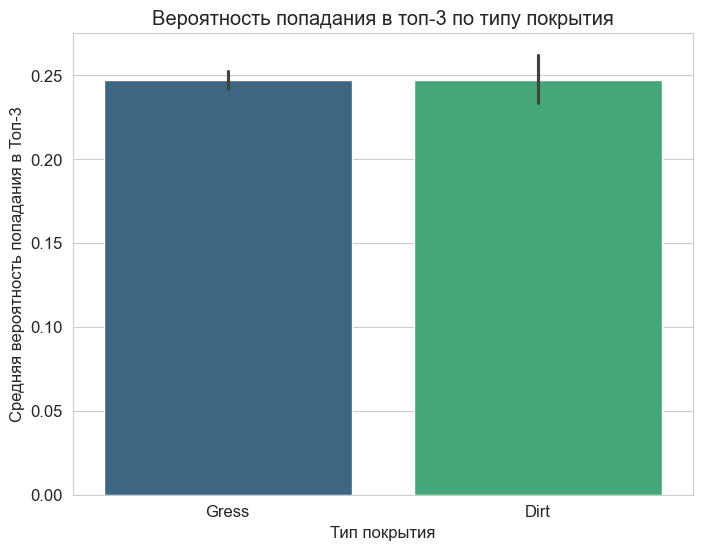

In [9]:
plt.figure(figsize=(8, 6))
sns.barplot(x='surface', y='target', data=df_fe, palette='viridis')
plt.title('Вероятность попадания в топ-3 по типу покрытия')
plt.xlabel('Тип покрытия')
plt.ylabel('Средняя вероятность попадания в Топ-3')
plt.savefig(os.path.join(images_dir, 'target_by_surface.png'))
plt.show()

C:\Users\shche\AppData\Local\Temp\ipykernel_11476\2572468503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='track', y='target', data=df_fe, palette='plasma')


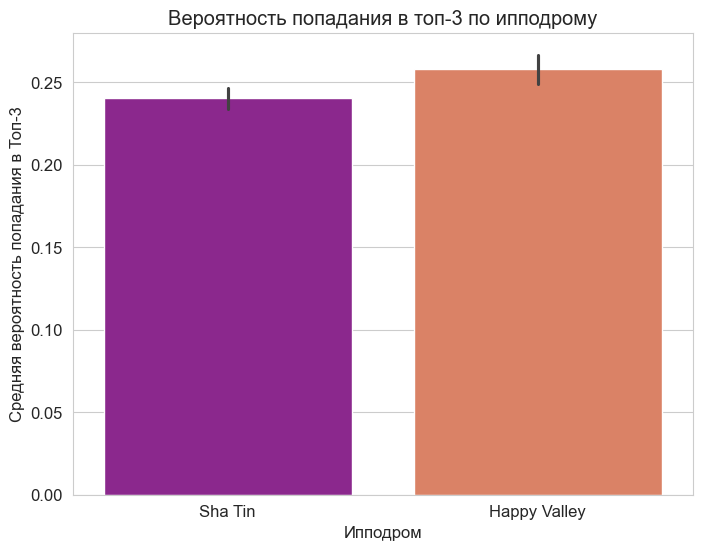

In [10]:

plt.figure(figsize=(8, 6))
sns.barplot(x='track', y='target', data=df_fe, palette='plasma')
plt.title('Вероятность попадания в топ-3 по ипподрому')
plt.xlabel('Ипподром')
plt.ylabel('Средняя вероятность попадания в Топ-3')
plt.savefig(os.path.join(images_dir, 'target_by_track.png'))
plt.show()


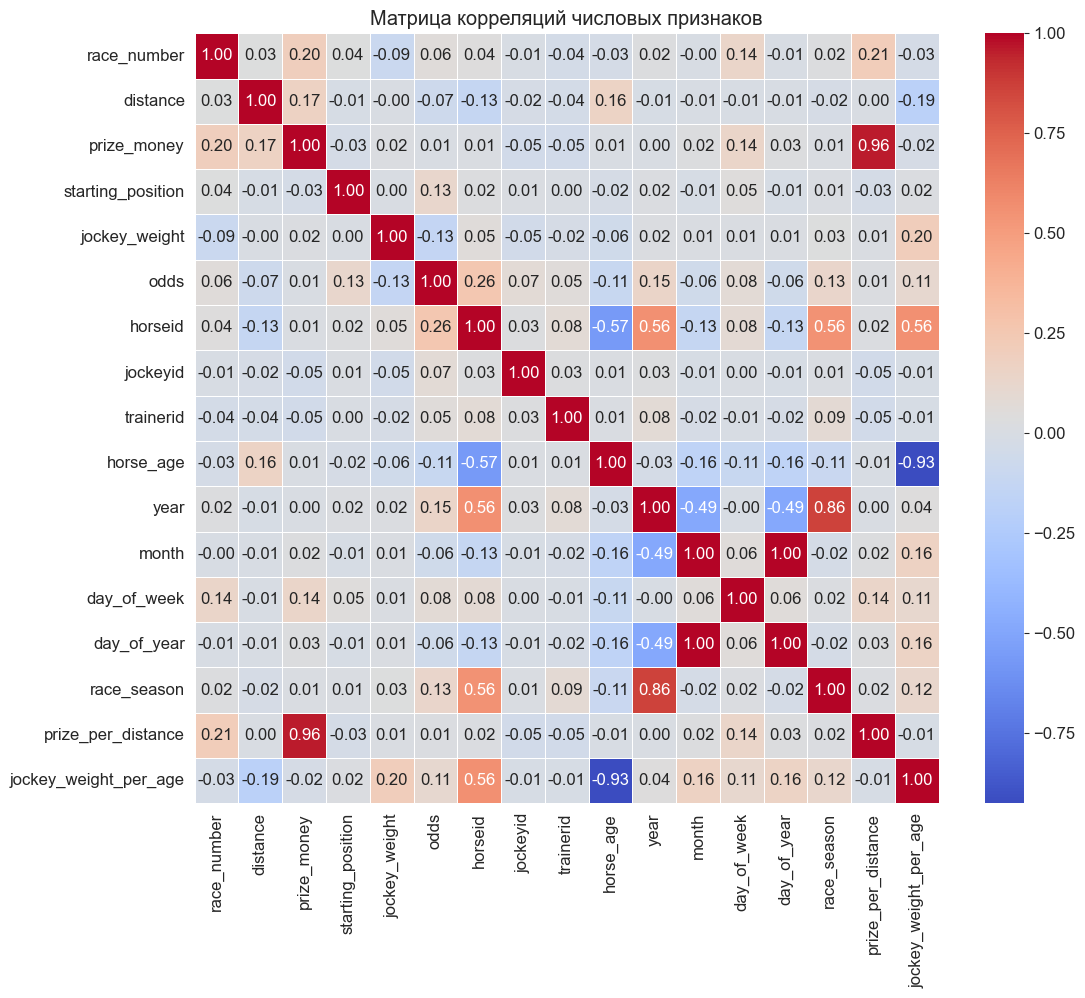

In [11]:
plt.figure(figsize=(12, 10))
numeric_cols = df_fe.select_dtypes(include=np.number).columns.tolist()
numeric_features_for_corr = [col for col in numeric_cols if col != 'target']
correlation_matrix = df_fe[numeric_features_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матрица корреляций числовых признаков')
plt.savefig(os.path.join(images_dir, 'numeric_correlation_matrix.png'))
plt.show()

2026-04-25 00:07:14,067 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\shche\AppData\Local\Temp\ipykernel_11476\511079515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='jockey_weight', data=df_fe, palette='coolwarm')
2026-04-25 00:07:14,098 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


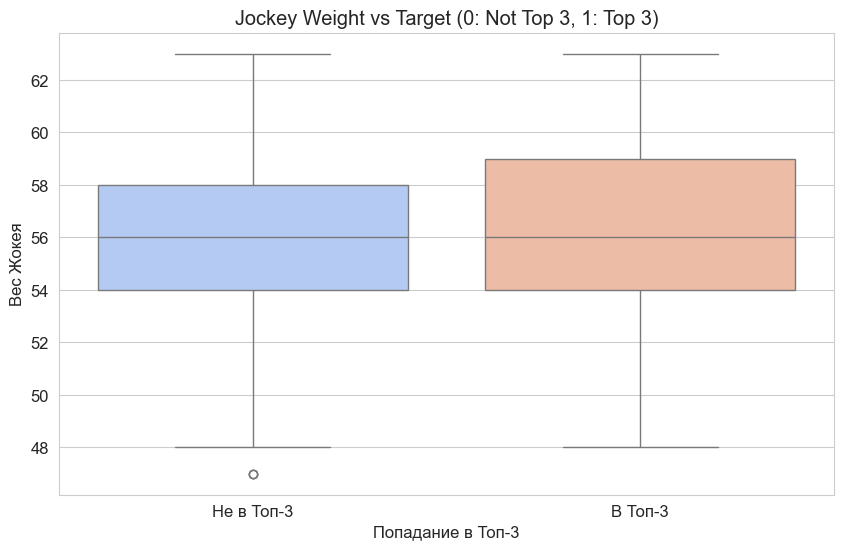

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='jockey_weight', data=df_fe, palette='coolwarm')
plt.title('Jockey Weight vs Target (0: Not Top 3, 1: Top 3)')
plt.xlabel('Попадание в Топ-3')
plt.ylabel('Вес Жокея')
plt.xticks([0, 1], ['Не в Топ-3', 'В Топ-3'])
plt.savefig(os.path.join(images_dir, 'jockey_weight_vs_target.png'))
plt.show()

2026-04-25 00:07:14,347 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\shche\AppData\Local\Temp\ipykernel_11476\604192869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='horse_age', data=df_fe, palette='coolwarm')
2026-04-25 00:07:14,367 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


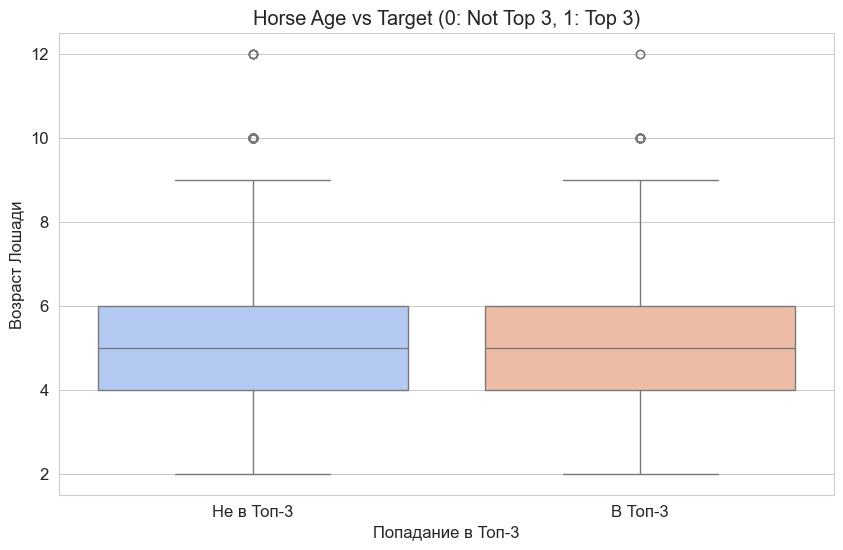


EDA завершен. Графики сохранены в ../report/images.


In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='horse_age', data=df_fe, palette='coolwarm')
plt.title('Horse Age vs Target (0: Not Top 3, 1: Top 3)')
plt.xlabel('Попадание в Топ-3')
plt.ylabel('Возраст Лошади')
plt.xticks([0, 1], ['Не в Топ-3', 'В Топ-3'])
plt.savefig(os.path.join(images_dir, 'horse_age_vs_target.png'))
plt.show()

print("\nEDA завершен. Графики сохранены в ../report/images.")